# **Exploratory Data Analysis**

<p>Explore the data and figure out what feature is more relevant to the target values.</p>

## EDA Steps

| Step | Description |
|------|-------------|
| 1    | Import Libraries |
| 2    | Load the Dataset |
| 3    | Dataset Overview |
| 4    | Missing Values Analysis |
| 5    | Target Variable Analysis |
| 6    | Univariate Analysis — Numerical Features |
| 7    | Univariate Analysis — Categorical Features |
| 8    | Bivariate Analysis — Survival vs Features |
| 9    | Correlation Analysis |
| 10   | Summary of EDA Findings |

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load Dataset

In [ ]:
df = pd.read_csv('data\\avocado.csv')
df = df.drop(['Unnamed: 0'], axis=1)
df

## 3. Data Overview

In [ ]:
df.info()

In [ ]:
df.describe(include='all')

## 4. Missing Values and Duplicate check

In [ ]:
print('Number of missing values in each column: {}'.format(df.isnull().sum()))
print("Number of Duplicated rows: {}".format(df.duplicated().sum()))

## 5. Target Variable Analysis

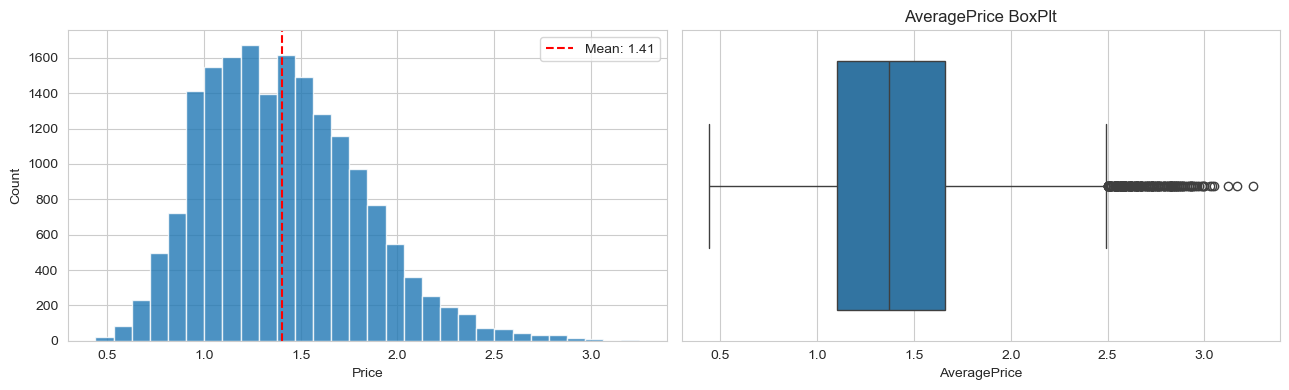

In [37]:
## Target Variable Analysis
fig, axes = plt.subplots(1, 2 ,figsize=(13, 4))

axes[0].hist(x=df['AveragePrice'], bins= 30, edgecolor='white', alpha = 0.8, )
axes[0].axvline(df['AveragePrice'].mean(), color= 'red', linestyle='--', label= f"Mean: {df['AveragePrice'].mean():.2f}")
axes[0].set_xlabel("Price")
axes[0].set_ylabel('Count')
axes[0].legend()

#sns.countplot(data= df, x= 'AveragePrice',hue=  'AveragePrice', palette='Reds', ax= axes[1])
sns.boxplot(x=df['AveragePrice'], ax= axes[1],)
axes[1].set_title("AveragePrice BoxPlt")

plt. tight_layout()
plt.show()

## 6. Univariate Analysis - Numberical Columns

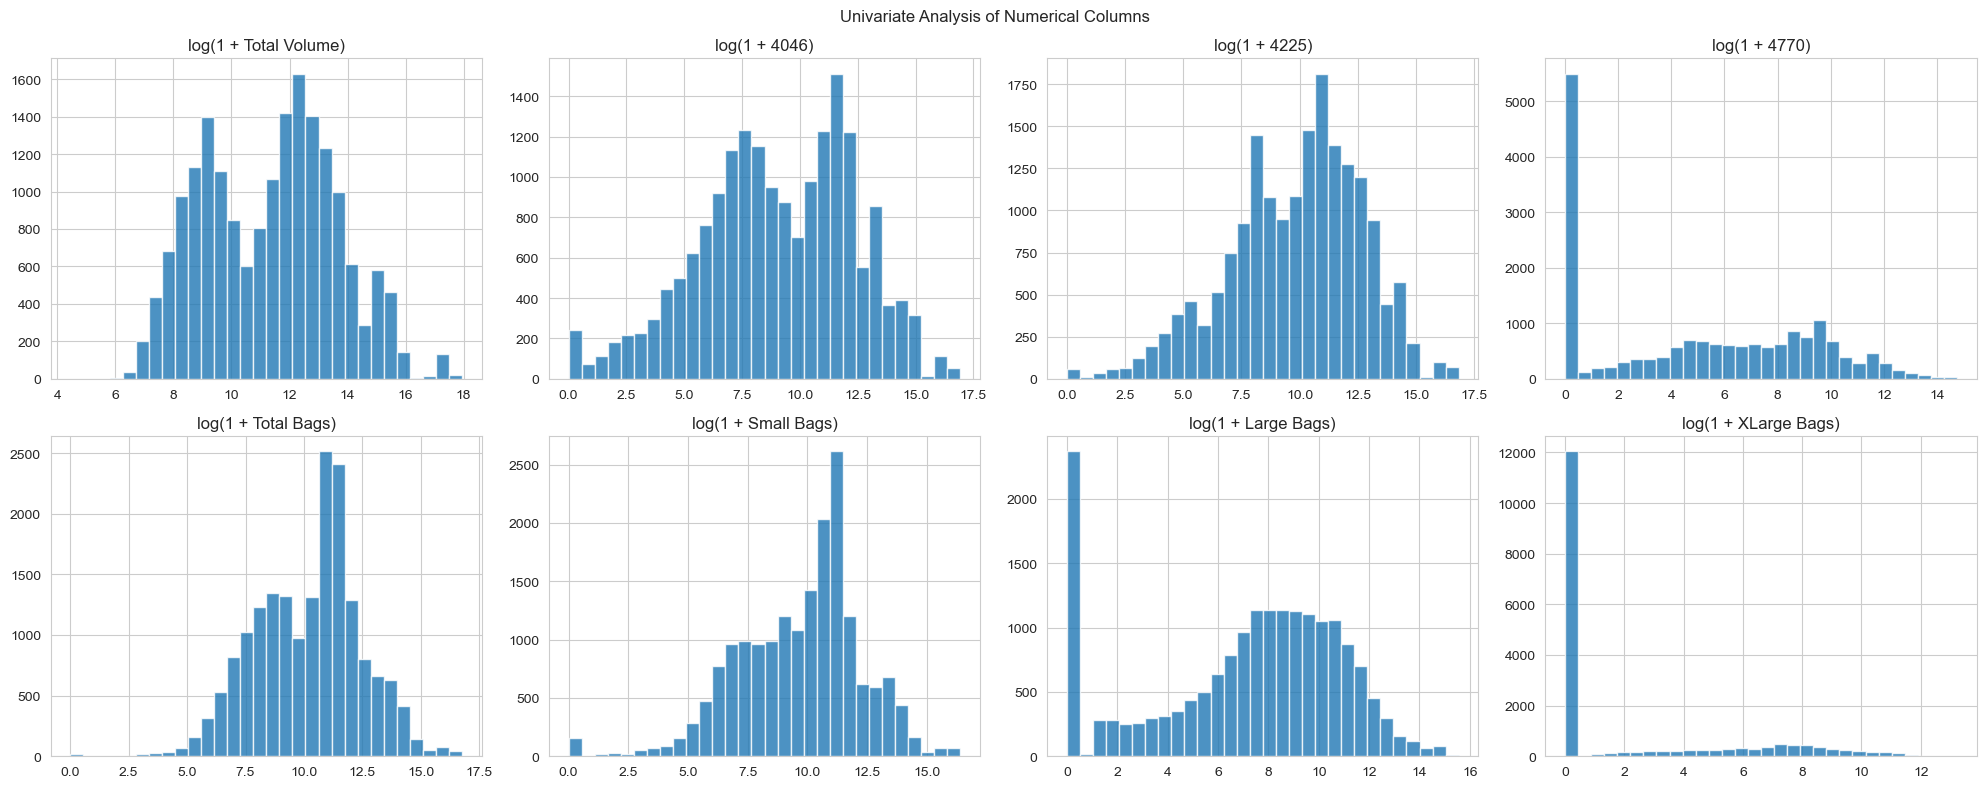

In [53]:
num_col = df.select_dtypes(exclude='object').columns.drop(["AveragePrice", 'year']).to_list()

fig , axes = plt.subplots(2,4, figsize=(20, 8))
axes = axes.flatten()
for i , v in enumerate(num_col):
    np.log1p(df[v]).hist(bins=30, ax=axes[i], alpha= 0.8, edgecolor='white')
    axes[i].set_title(f"log(1 + {v})")
plt.suptitle("Univariate Analysis of Numerical Columns")
plt.tight_layout()
plt.show()


## 7. Univariate Analysis - Categorical Columns

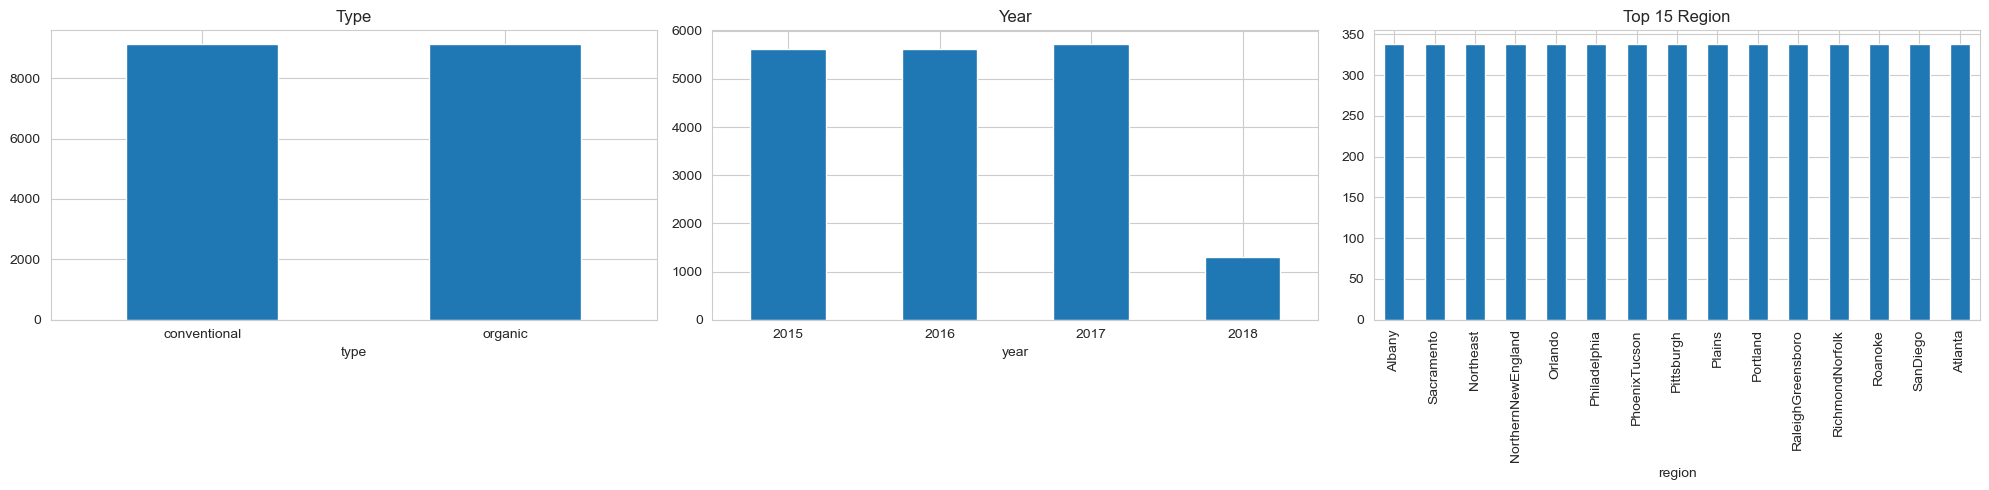

In [39]:
cat = ['type', 'region', 'year']

fig, axes= plt.subplots(1, 3, figsize=(20, 5))

df['type'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Type');  axes[0].tick_params(axis='x',rotation=0)

df['year'].value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title('Year');  axes[1].tick_params(axis='x',rotation=0)

df['region'].value_counts().head(15).plot(kind='bar', ax=axes[2])
axes[2].set_title('Top 15 Region');  axes[2].tick_params(axis='x', )#rotation=45)

plt.tight_layout(); plt.show()

## 8. Bivariate Analysis

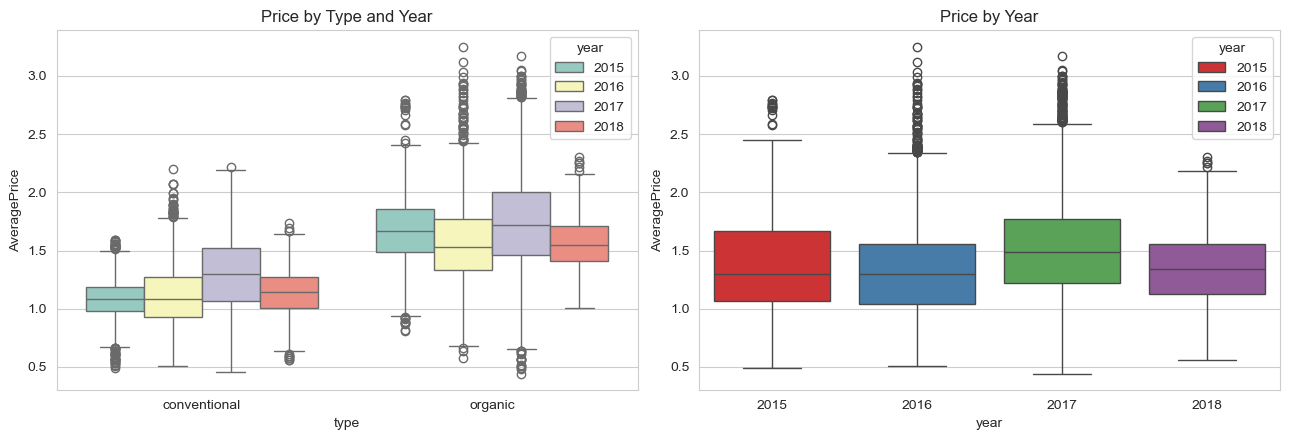

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x='type',hue='year', y='AveragePrice', ax=axes[0], palette='Set3')
axes[0].set_title("Price by Type and Year")

sns.boxplot(data=df, x='year',hue='year', y='AveragePrice', ax=axes[1], palette='Set1')
axes[1].set_title("Price by Year")

plt.tight_layout(); plt.show()

In [41]:
print("Mean price by type")

print(df.groupby('type')['AveragePrice'].agg(['mean', 'median', 'count']).round(3))

Mean price by type
               mean  median  count
type                              
conventional  1.158    1.13   9126
organic       1.654    1.63   9123


### Time Series of Mean Price

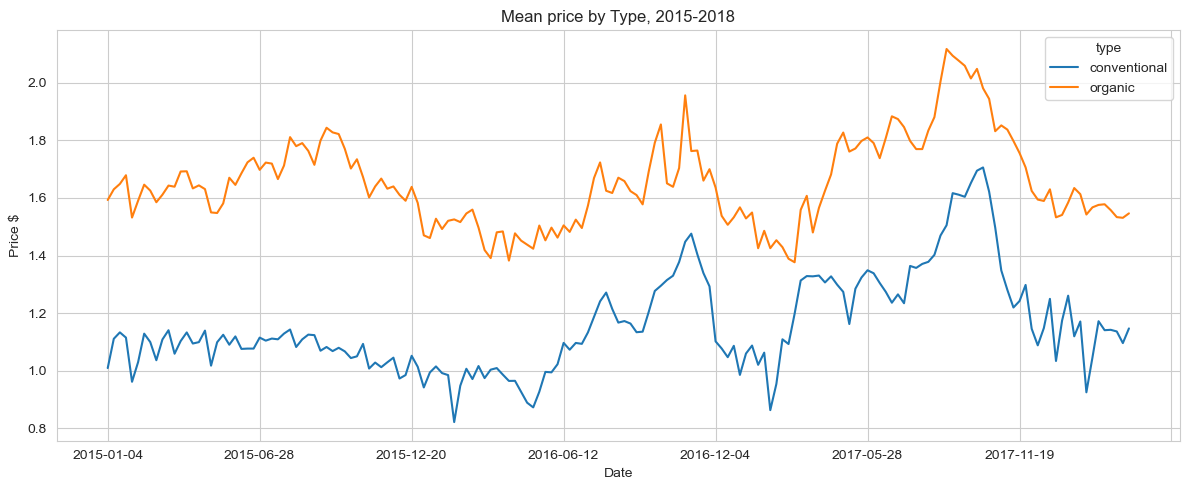

In [42]:
ts = df.groupby(['Date', 'type'])['AveragePrice'].mean().unstack()
plt.figure(figsize=(12,5))
ts.plot(ax=plt.gca())
plt.title('Mean price by Type, 2015-2018')
plt.ylabel('Price $')
#plt.grid(True)
plt.tight_layout(); plt.show()

### Region Effect (top vs bottom)

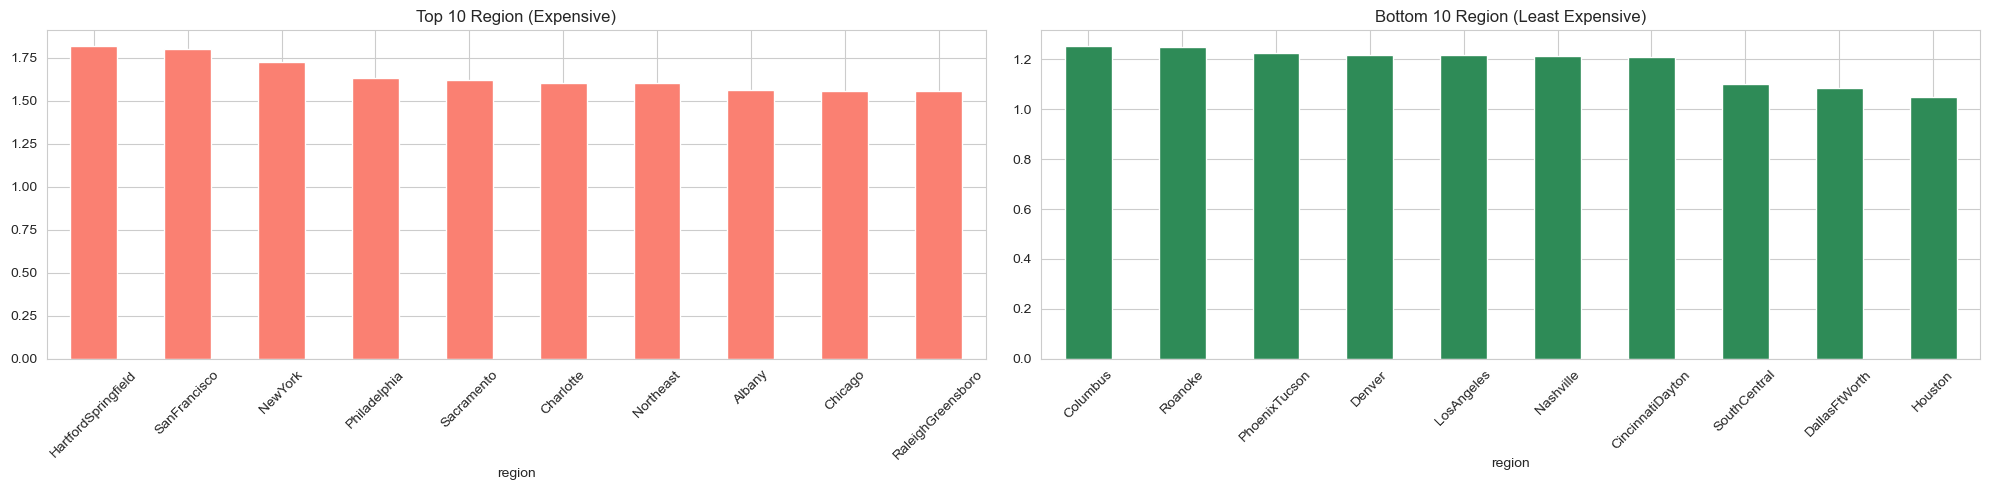

In [43]:
reg_mean = df.groupby('region')['AveragePrice'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20,5))

reg_mean.head(10).plot(kind='bar', ax= axes[0], color='salmon')
axes[0].set_title("Top 10 Region (Expensive)")
axes[0].tick_params(axis='x', rotation= 45)

reg_mean.tail(10).plot(kind='bar', ax= axes[1],color= 'seagreen')
axes[1].set_title("Bottom 10 Region (Least Expensive)")
axes[1].tick_params(axis='x', rotation= 45)


plt.tight_layout(); plt.show()

## 9. Correlation Analysis

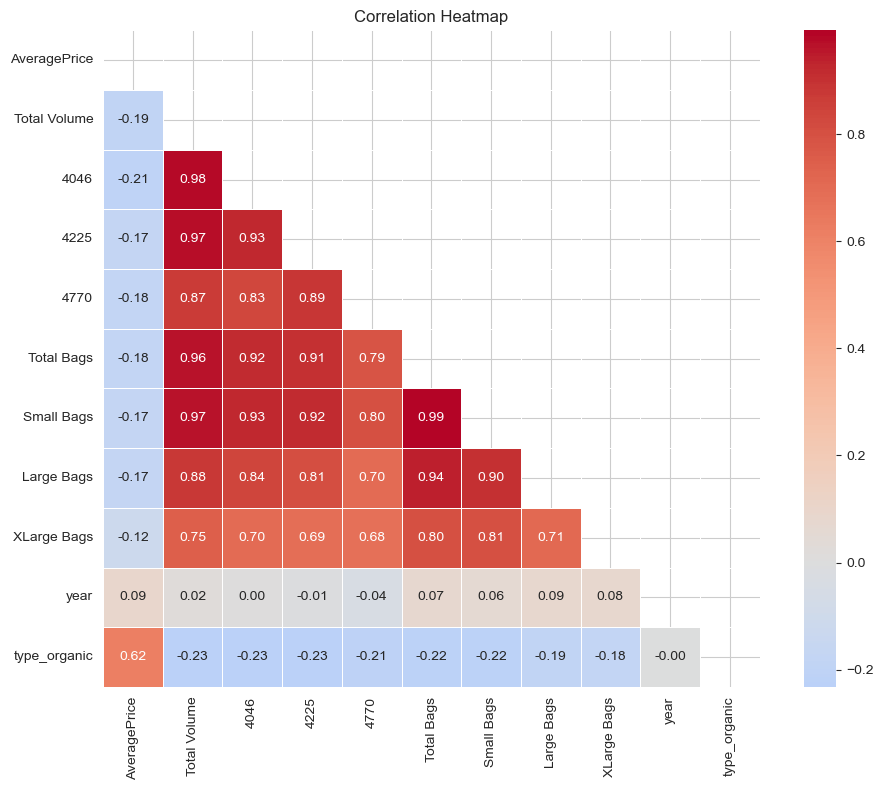

In [44]:
df_corr = df.copy()
df_corr['type_organic'] = (df_corr['type'] == 'organic').astype(int)

plt.figure(figsize=(10, 8))
corr_data = df_corr.drop(columns=['type', 'Date', 'region']).corr()
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(corr_data, annot=True, mask=mask, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap")

plt.tight_layout(); plt.show()

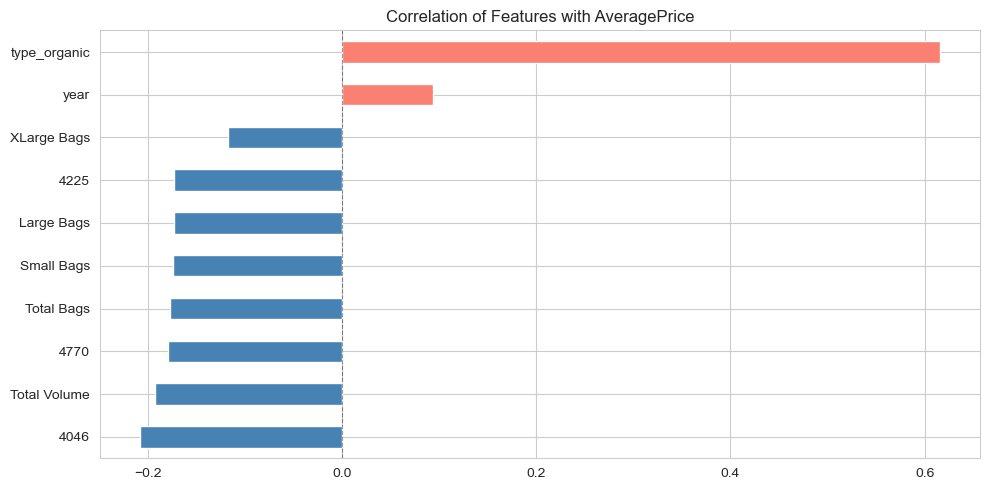

type_organic    0.616
year            0.093
XLarge Bags    -0.118
4225           -0.173
Large Bags     -0.173
Small Bags     -0.175
Total Bags     -0.177
4770           -0.179
Total Volume   -0.193
4046           -0.208
Name: AveragePrice, dtype: float64


In [45]:
from networkx import center


tar_corr = df_corr.drop(columns=['Date', 'type', 'region']).corr()['AveragePrice'].drop('AveragePrice').sort_values(ascending= False)


plt.figure(figsize=(10, 5))
tar_corr.plot(kind='barh',
            color = ['salmon' if x > 0 else 'steelblue' for x in tar_corr],)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    
plt.title("Correlation of Features with AveragePrice")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show() 
print(tar_corr.round(3))

### Pair Plot Top Predictor

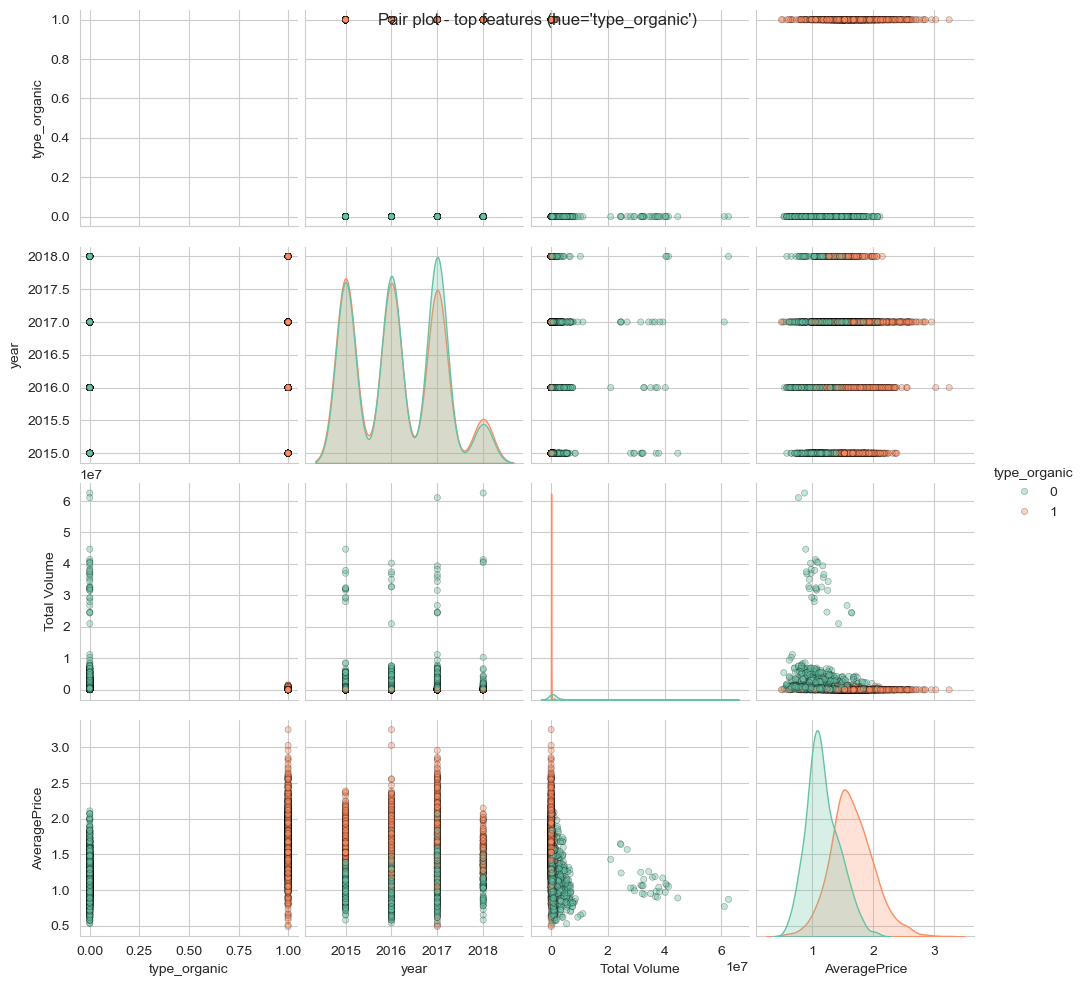

In [46]:
sample = df.sample(n=3000, random_state=42)
sample['type_organic'] = (sample['type'] == 'organic').astype(int)

sns.pairplot(data=sample, vars=['type_organic','year','Total Volume','AveragePrice'],
            hue='type_organic', palette='Set2', diag_kind='kde', plot_kws={'alpha':0.4, 's': 20, 'edgecolor': 'k'})
plt.suptitle("Pair plot - top features (hue='type_organic')")
plt.show()

## 10. Key EDA Findings

| # | Finding |
|---|--------|
| 1 | **`type` is the dominant predictor** — organic avocados are ~50-60% more expensive than conventional, on average $1.65 vs $1.16 |
| 2 | **Volume is negatively correlated with price** — high-volume regions/weeks see lower per-unit prices (basic supply effect, but the magnitude is small: r ≈ −0.19) |
| 3 | **Year matters mildly** — 2017 had the highest mean prices, 2015 the lowest |
| 4 | **Region effects span ~$0.50** between cheapest (e.g. Houston, Phoenix-Tucson) and most expensive (e.g. SanFrancisco, NewYork) |
| 5 | **Volume features are heavily right-skewed** — log-transform recommended for linear models |
| 6 | **No missing values, no duplicates** — already clean |
| 7 | **Time-series structure**: the dataset has weekly observations 2015-2018 — for a serious model we'd want time-aware CV instead of random splits |